# El techo que no existe

Durante casi **40 años**, cada vez que el viento solar golpeaba con fuerza, la respuesta magnética de la Tierra parecía chocar contra un techo invisible. Empujaras lo que empujaras, no subía más. Los físicos lo llamaron *saturación* y propusieron una decena de explicaciones. Ninguna cerró el debate.

Este paper de 2026 dice algo incómodo: **ese techo nunca existió.** Es un espejismo estadístico — un efecto llamado *regresión a la media* que aparece cuando mides algo extremo con un instrumento impreciso.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** *Regression to the mean can explain saturation of geomagnetic storms* — Sivadas et al., **Nature** (2026)
**DOI:** [10.1038/s41586-026-10757-4](https://doi.org/10.1038/s41586-026-10757-4)

[![Abrir en Colab]({colab_badge})](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-07-15-regresion-media-geomagnetica/notebook.ipynb)


## De qué va esto

El viento solar es un chorro de plasma que sale del Sol y empuja el campo magnético de la Tierra. Cuando empuja fuerte, arma tormentas geomagnéticas: auroras, satélites que fallan, redes eléctricas que se estresan.

Para medir cuánto empuja, los científicos usan un índice de casquete polar construido con magnetómetros en tierra. La cuenta es sencilla al principio: más viento solar, más respuesta. **Lineal.** Pero en los datos, al llegar a los valores más extremos, la respuesta dejaba de crecer. Se aplanaba. Ese aplanamiento es la *saturación* — y de ahí salió toda una industria de teorías físicas para explicarlo.


In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
COLOR_DATOS      = '#2563EB'   # curva medida (lo que ves)
COLOR_IDENTIDAD  = '#D97706'   # respuesta lineal real (sin error)
COLOR_ALERTA     = '#DC2626'   # el hueco / la corrección
COLOR_CONTEXTO   = '#BBBBBB'
FUENTE = 'Fuente: Sivadas et al. (2026), Nature | Datos: Zenodo 10.5281/zenodo.17559999'

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Estilo CaM (local → fallback GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Datos
curva = pd.read_csv('datos/curva_regresion_media.csv')
estudios = pd.read_csv('datos/saturacion_estudios.csv')

print(f'Curva de regresión a la media: {len(curva)} puntos de driver medido')
print(f'  driver medido: {curva.driver_medido.min():.2f} → {curva.driver_medido.max():.2f}')
print(f'  muestras totales simuladas: {int(curva.n_muestras.sum()):,}'.replace(',', '.'))
print(f'\nEstudios de saturación: {len(estudios)} ({estudios.anio.min()}–{estudios.anio.max()})')
print(f'  límite reportado (mediana): {estudios.limite_saturacion_mvm.median():.1f} mV/m')


Curva de regresión a la media: 29 puntos de driver medido
  driver medido: 0.20 → 5.70
  muestras totales simuladas: 198.000

Estudios de saturación: 9 (1981–2005)
  límite reportado (mediana): 4.0 mV/m


## El truco, en una gráfica

La simulación es honesta hasta el hueso: dentro del modelo, **la respuesta de la Tierra es perfectamente lineal**. No tiene techo. Le metemos ruido de medición realista al viento solar y volvemos a mirar.

Aquí está.


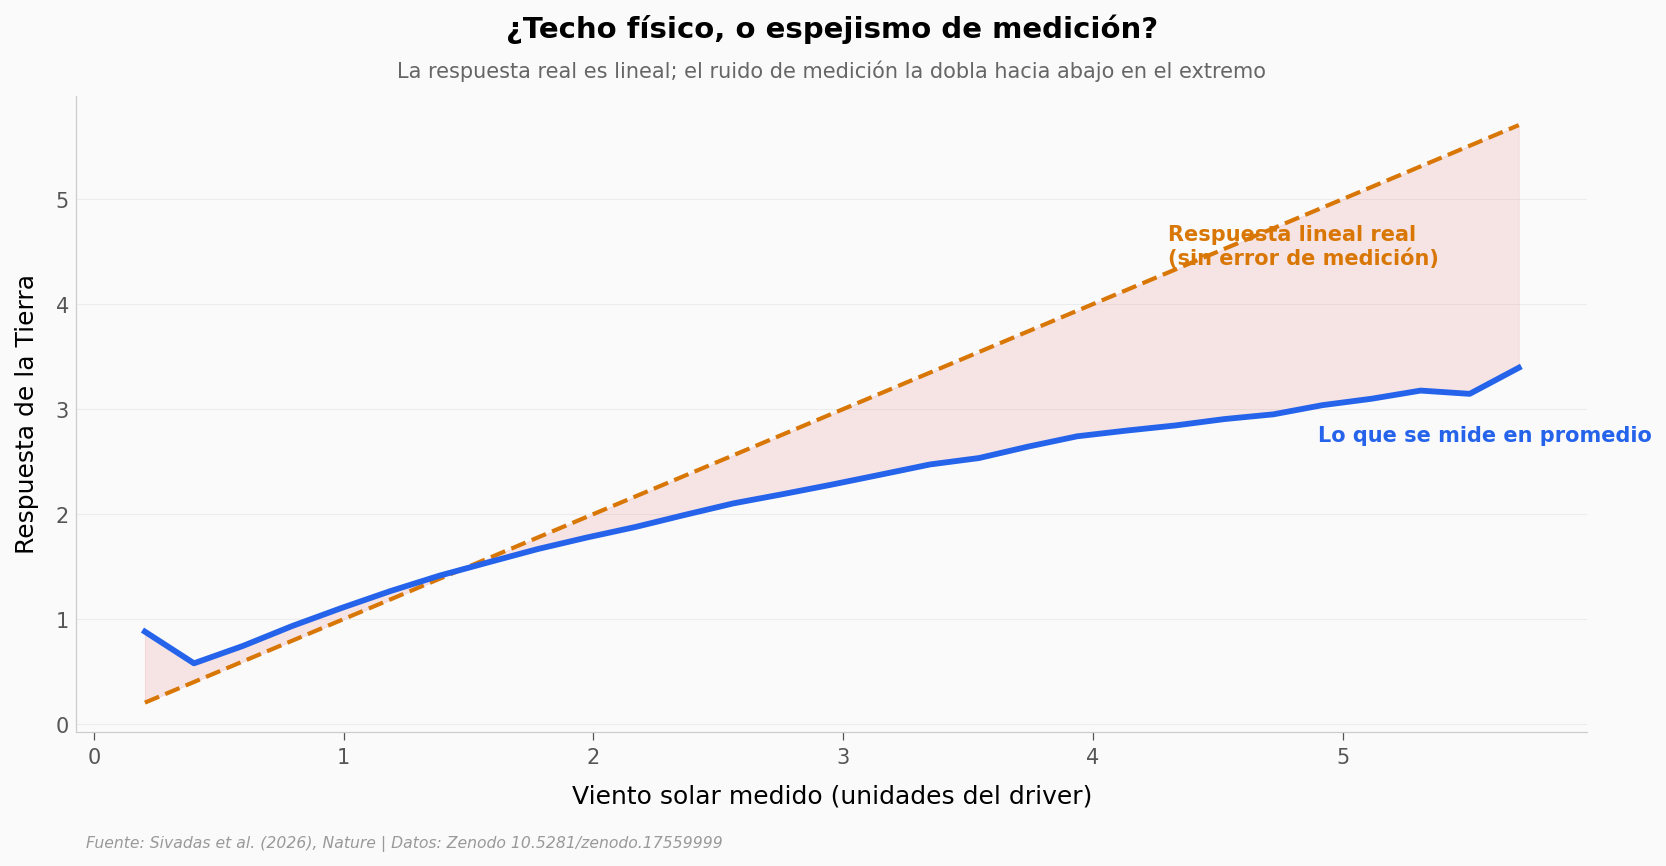

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Linea de identidad = respuesta lineal real (lo que trazaria un mundo sin error)
ax.plot(curva.driver_medido, curva.identidad,
        color=COLOR_IDENTIDAD, linewidth=2.0, linestyle='--', zorder=3)
# Curva medida = E[respuesta verdadera | driver medido]
ax.plot(curva.driver_medido, curva.respuesta_verdadera_media,
        color=COLOR_DATOS, linewidth=2.8, zorder=5)

# Sombrear el hueco (la saturacion aparente)
ax.fill_between(curva.driver_medido, curva.respuesta_verdadera_media, curva.identidad,
                color=COLOR_ALERTA, alpha=0.10, zorder=2)

# Inline labels (sin legend box)
ax.text(4.3, 4.55, 'Respuesta lineal real\n(sin error de medición)', color=COLOR_IDENTIDAD,
        fontsize=10, fontweight='bold', ha='left', va='center')
ax.text(4.9, 2.75, 'Lo que se mide en promedio', color=COLOR_DATOS,
        fontsize=10, fontweight='bold', ha='left', va='center')

ax.set_title('¿Techo físico, o espejismo de medición?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'La respuesta real es lineal; el ruido de medición la dobla hacia abajo en el extremo',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Viento solar medido (unidades del driver)')
ax.set_ylabel('Respuesta de la Tierra')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/hero_regresion_media.png', dpi=200, bbox_inches='tight')
plt.show()


En el grueso de los datos —el viento solar de todos los días— las dos curvas van casi montadas: medir con error apenas mueve el promedio. El desajuste vive en los extremos, y es en el alto donde nació el mito: al empujar hacia el viento fuerte, la curva medida se despega y cae por debajo de la respuesta real.

Ese hueco entre las dos **es la saturación** — solo que aquí sabemos, con certeza absoluta, que la respuesta verdadera era una recta. No hubo ningún techo físico. El doblez lo puso el ruido del instrumento, no la naturaleza. (Fíjate también en el arranque: en el extremo bajo la curva medida queda por *encima* — el mismo efecto, al revés.)


## ¿Por qué el extremo y no el centro?

El error de medición no empuja igual en todas partes. Cuando mides una tormenta gigante, buena parte de lo que registras como "gigante" es un empujón de suerte del error. La verdad detrás de esa medición casi siempre es más modesta — más cerca del montón. Eso es *regresión a la media*, y arrastra el promedio hacia el centro justo donde los datos son raros.

Midamos ese arrastre directo: cuánto se aparta la curva medida de la recta real en cada nivel del viento solar.


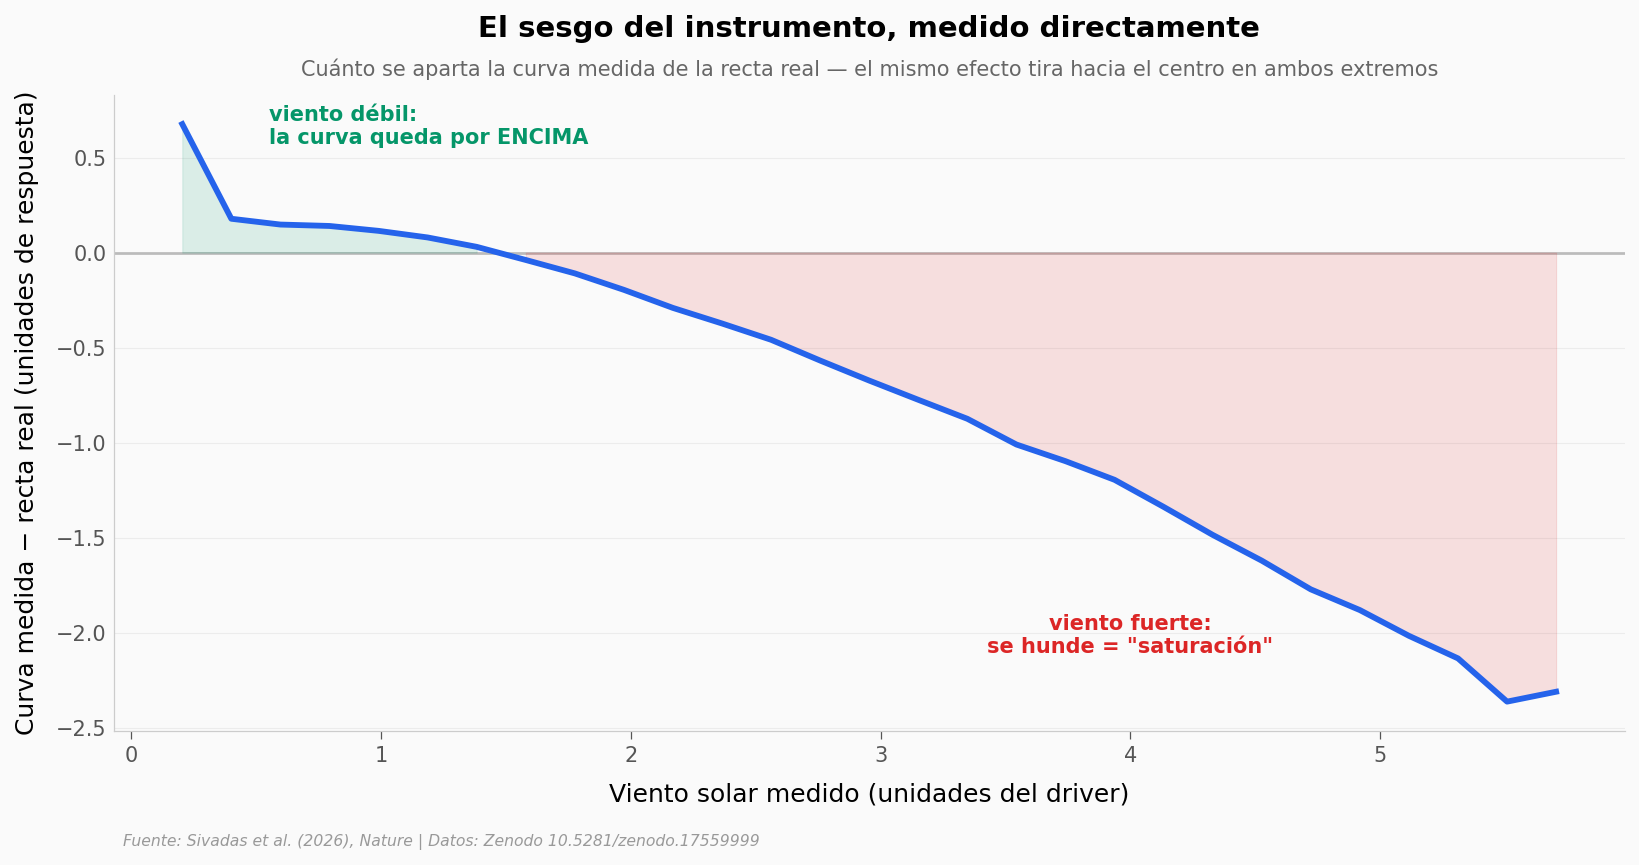

Máxima desviación hacia abajo (extremo alto): -2.36 unidades de respuesta.
El sesgo cambia de signo cerca de driver ≈ 1.4: debajo tira hacia arriba, encima tira hacia abajo.


In [3]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Desviacion en unidades de respuesta (NO %: la señal cruza cero, ver regla de escalas)
desvio = curva.respuesta_verdadera_media - curva.identidad

ax.axhline(0, color=COLOR_CONTEXTO, linewidth=1.3, zorder=2)
ax.plot(curva.driver_medido, desvio, color=COLOR_DATOS, linewidth=2.8, zorder=5)
ax.fill_between(curva.driver_medido, desvio, 0, where=(desvio < 0),
                color=COLOR_ALERTA, alpha=0.13, zorder=3)
ax.fill_between(curva.driver_medido, desvio, 0, where=(desvio >= 0),
                color='#059669', alpha=0.13, zorder=3)

ax.text(0.55, 0.55, 'viento débil:\nla curva queda por ENCIMA', color='#059669',
        fontsize=10, fontweight='bold', ha='left', va='bottom')
ax.text(4.0, -1.9, 'viento fuerte:\nse hunde = "saturación"', color=COLOR_ALERTA,
        fontsize=10, fontweight='bold', ha='center', va='top')

ax.set_title('El sesgo del instrumento, medido directamente', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cuánto se aparta la curva medida de la recta real — el mismo efecto tira hacia el centro en ambos extremos',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Viento solar medido (unidades del driver)')
ax.set_ylabel('Curva medida − recta real (unidades de respuesta)')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/sesgo_por_nivel.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Máxima desviación hacia abajo (extremo alto): {desvio.min():.2f} unidades de respuesta.')
print(f'El sesgo cambia de signo cerca de driver ≈ {curva.driver_medido[desvio.abs().idxmin()]:.1f}: '
      f'debajo tira hacia arriba, encima tira hacia abajo.')


## Una pista escondida en 24 años de estudios

Si la saturación fuera de verdad, sería un número fijo de la física. Pero si es un artefacto del error de medición, debería **encogerse a medida que los instrumentos mejoran**: menos error, menos regresión a la media, techo aparente más alto.

Reunimos nueve estudios que reportaron un límite de saturación entre 1981 y 2005 y miramos cómo cambió con el tiempo.


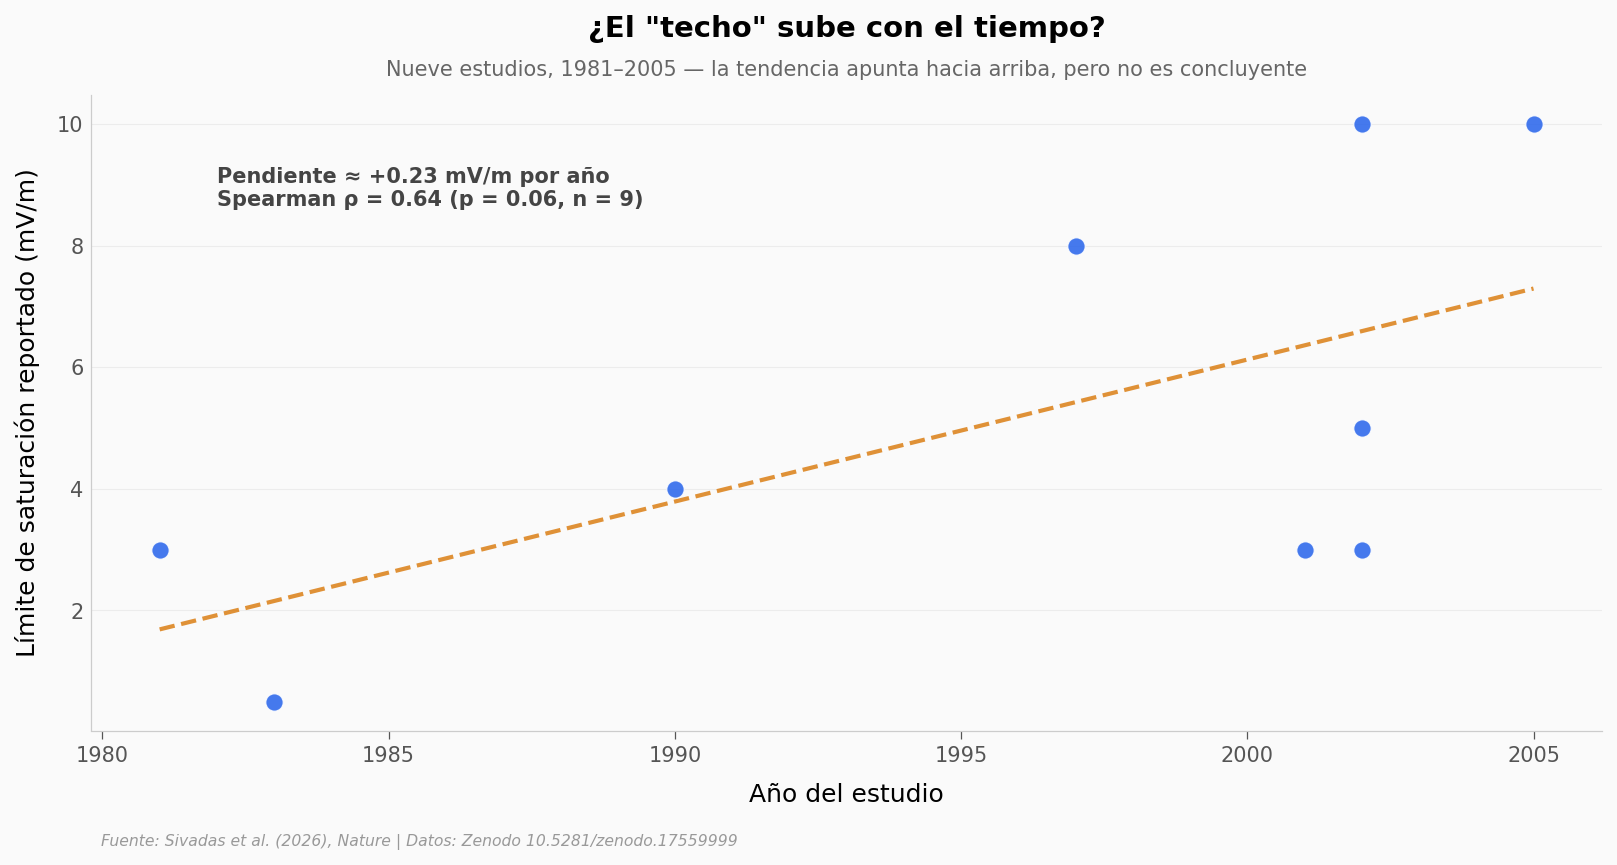

Spearman ρ = 0.641, p = 0.063
Pearson  r = 0.619, p = 0.076  (R² = 0.38)
n = 9 estudios — muestra pequeña: tendencia sugestiva, no significativa a 0,05.


In [4]:
fig, ax = plt.subplots(figsize=(13, 5.5))

x = estudios.anio.values.astype(float)
y = estudios.limite_saturacion_mvm.values.astype(float)

ax.scatter(x, y, color=COLOR_DATOS, s=70, alpha=0.85,
           edgecolors='white', linewidths=0.6, zorder=5)

# Tendencia OLS (solo como guia visual — n=9, no significativa)
slope, intercept = np.polyfit(x, y, 1)
xs = np.array([x.min(), x.max()])
ax.plot(xs, slope * xs + intercept, color=COLOR_IDENTIDAD, linewidth=2.0,
        linestyle='--', alpha=0.8, zorder=3)

# Correlaciones (Spearman por defecto — regla 33)
rho, p_sp = stats.spearmanr(x, y)
r_pe, p_pe = stats.pearsonr(x, y)

ax.text(1982, 9.3, f'Pendiente ≈ +{slope:.2f} mV/m por año\nSpearman ρ = {rho:.2f} (p = {p_sp:.2f}, n = 9)',
        fontsize=10, color='#444444', ha='left', va='top', fontweight='bold')

ax.set_title('¿El "techo" sube con el tiempo?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Nueve estudios, 1981–2005 — la tendencia apunta hacia arriba, pero no es concluyente',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Año del estudio')
ax.set_ylabel('Límite de saturación reportado (mV/m)')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/tendencia_estudios.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Spearman ρ = {rho:.3f}, p = {p_sp:.3f}')
print(f'Pearson  r = {r_pe:.3f}, p = {p_pe:.3f}  (R² = {r_pe**2:.2f})')
print(f'n = {len(x)} estudios — muestra pequeña: tendencia sugestiva, no significativa a 0,05.')


## ¿De cuánto es el error?

Volvamos a la simulación y pongámosle número al hueco. ¿Cuánto se hunde la curva medida por debajo de la respuesta lineal real, justo en el extremo?


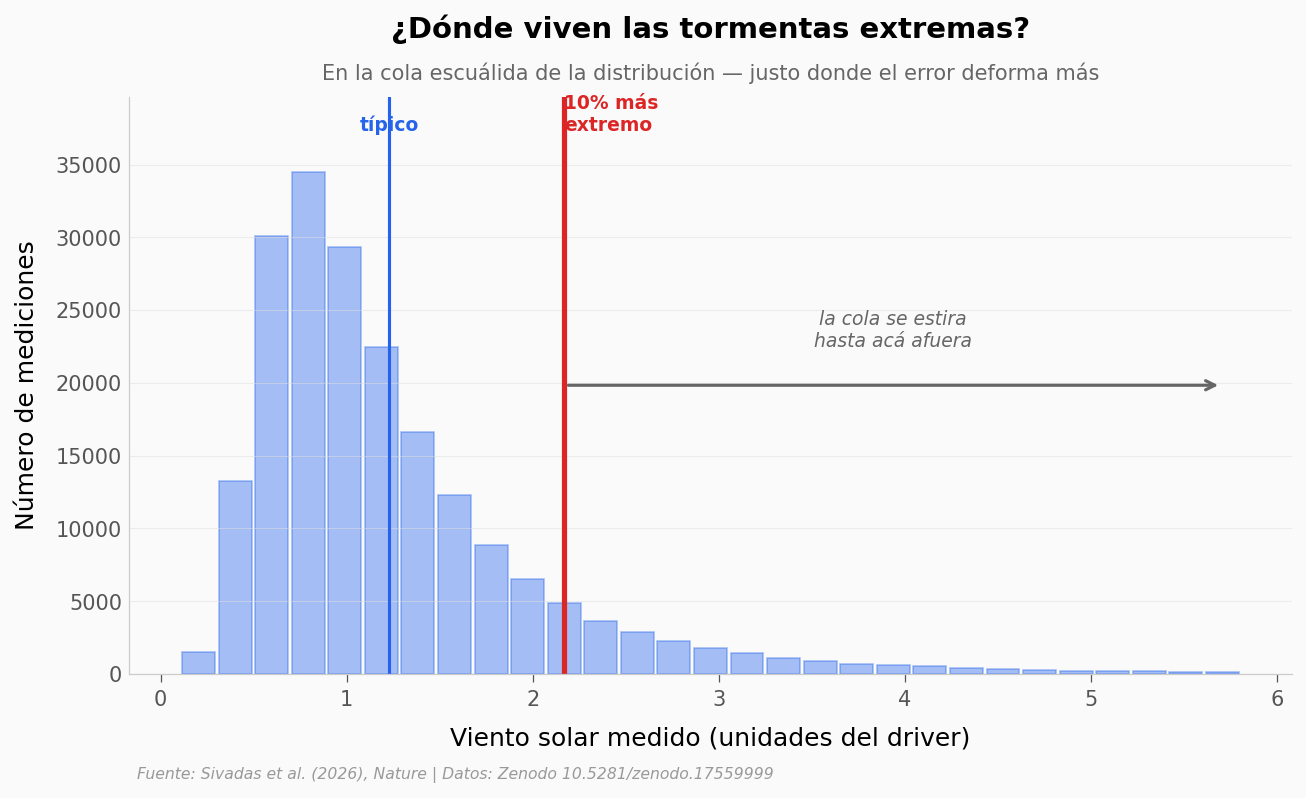

El pico concentra 34.505 mediciones; la punta extrema apenas 145 — 238x menos.
Decil más extremo de las mediciones: la curva cae ~30% por debajo de la recta real.
En la punta misma: ~41% → el impacto real sería ~1.7x el que se midió.
La respuesta parecía frenarse; en realidad solo la estábamos midiendo torcida.


In [5]:
# Reconstruir la distribución del driver medido a partir de los conteos por tramo
fig, ax = plt.subplots(figsize=(10, 5))

driver = curva.driver_medido.values
pesos  = curva.n_muestras.values

ax.bar(driver, pesos, width=np.diff(driver).mean() * 0.9,
       color=COLOR_DATOS, alpha=0.4, edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = pesos.max() * 1.15
ax.set_ylim(0, y_max)

media_driver = np.average(driver, weights=pesos)      # regla 34: ponderar por n
# Decil superior de las MEDICIONES (top 10% de la distribución, no del rango)
muestras = np.repeat(driver, (pesos/pesos.min()).astype(int))
umbral_ext = np.percentile(muestras, 90)

ax.axvline(media_driver, color=COLOR_DATOS, linewidth=1.5)
ax.axvline(umbral_ext,   color=COLOR_ALERTA, linewidth=2.5)
ax.annotate('', xy=(driver.max(), y_max*0.5), xytext=(umbral_ext, y_max*0.5),
            arrowprops=dict(arrowstyle='->', color='#666666', lw=1.5))
ax.text((umbral_ext+driver.max())/2, y_max*0.56, 'la cola se estira\nhasta acá afuera',
        fontsize=9, color='#666666', ha='center', va='bottom', style='italic')
ax.text(media_driver, y_max*0.94, 'típico', color=COLOR_DATOS, fontsize=9,
        fontweight='bold', ha='center')
ax.text(umbral_ext, y_max*0.94, '10% más\nextremo', color=COLOR_ALERTA, fontsize=9,
        fontweight='bold', ha='left')

ax.set_title('¿Dónde viven las tormentas extremas?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'En la cola escuálida de la distribución — justo donde el error deforma más',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Viento solar medido (unidades del driver)')
ax.set_ylabel('Número de mediciones')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_driver.png', dpi=200, bbox_inches='tight')
plt.show()

# Cuán rara es la cola + hueco en el decil superior de las mediciones + en la punta misma
n_pico = int(curva.n_muestras.max()); n_cola = int(curva.n_muestras.iloc[-1])
print(f'El pico concentra {n_pico:,} mediciones; la punta extrema apenas {n_cola} — {n_pico/n_cola:.0f}x menos.'.replace(',', '.'))
top = curva[curva.driver_medido >= umbral_ext]
gap_decil = ((top.identidad - top.respuesta_verdadera_media) / top.identidad).mean()
tip = curva.iloc[-1]
gap_tip = (tip.identidad - tip.respuesta_verdadera_media) / tip.identidad
print(f'Decil más extremo de las mediciones: la curva cae ~{gap_decil*100:.0f}% por debajo de la recta real.')
print(f'En la punta misma: ~{gap_tip*100:.0f}% → el impacto real sería ~{1/(1-gap_tip):.1f}x el que se midió.')
print('La respuesta parecía frenarse; en realidad solo la estábamos midiendo torcida.')


## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|:-----------:|---------|
| Un modelo con respuesta **lineal** + error de medición reproduce la saturación aparente | ✅ | Simulación controlada: la verdad es lineal por construcción y la curva medida se dobla igual. Como el ruido está bajo control, aquí el vínculo causal (error → saturación falsa) sí es firme. |
| En el decil más extremo la curva medida cae ~30% por debajo de la recta real | ✅ | Promedio sobre el 10% más extremo de las mediciones simuladas. En la punta misma llega a ~41%. La cola tiene pocos datos, así que es un orden de magnitud, no una cifra fina. |
| El límite de saturación reportado sube con el año del estudio | ⚠️ | Tendencia positiva (ρ = 0,64) pero con **solo 9 estudios** y p ≈ 0,06: apunta en esa dirección, no la demuestra. |
| Corrigiendo el error, el impacto de tormentas extremas puede ser el doble | ⚠️ | El paper lo enmarca como posibilidad (*can be twice as large*), no como hecho cerrado. En la punta de la simulación el hueco de ~41% implica un impacto real de ~1,7x — se acerca a ese doble sin cerrarlo. |

> **Limitaciones:** la parte cuantitativa vive en una simulación Monte Carlo (semilla 42), no en observaciones crudas — muestra que el artefacto *puede* explicar la saturación, no que sea la única causa. Los nueve estudios reportan un solo número cada uno, sin barras de error, y n = 9 es muy poco para afirmar una tendencia temporal. Las unidades del driver están normalizadas para la demostración.


## Ahora tú

1. **¿Y si el instrumento fuera perfecto?** En la celda de abajo, ¿qué le pasaría al hueco si el error de medición fuera cero? (pista: sin ruido, la curva medida se pega a la recta real — prueba escalando la columna del hueco).
2. **¿Cuánto pesa la cola?** ¿Qué fracción de todas las mediciones cae en el decil extremo del viento solar? (pista: `curva.n_muestras` y `curva.driver_medido.quantile(0.90)`).
3. **¿Aguanta la tendencia sin los extremos?** Quita el estudio con el límite más alto y el más bajo de `estudios` y recalcula Spearman. ¿Sigue apuntando hacia arriba?


In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 2: ¿hasta dónde se estira el viento solar extremo, y cuánto se dobla ahí la curva?
muestras = np.repeat(curva.driver_medido, (curva.n_muestras/curva.n_muestras.min()).astype(int))
umbral = np.percentile(muestras, 90)   # decil superior de las mediciones
cola = curva[curva.driver_medido >= umbral]
print(f'Umbral del decil más extremo: viento solar ≥ {umbral:.2f}')
print(f'Ese 10% de mediciones se estira hasta {curva.driver_medido.max():.1f} (más de 2x el umbral)')
print(f'Hueco promedio en ese decil: ~{(((cola.identidad-cola.respuesta_verdadera_media)/cola.identidad).mean())*100:.0f}% por debajo de la recta real')


Umbral del decil más extremo: viento solar ≥ 2.17
Ese 10% de mediciones se estira hasta 5.7 (más de 2x el umbral)
Hueco promedio en ese decil: ~30% por debajo de la recta real


## Fuentes

**Paper**: [Regression to the mean can explain saturation of geomagnetic storms](https://doi.org/10.1038/s41586-026-10757-4)  
*Nature, 2026-07-15*

**Datos**: [Código archivado del paper (Zenodo)](https://doi.org/10.5281/zenodo.17559999)  
*Reproducción del Monte Carlo (Code 4) y de la tabla de estudios (Extended Data Table 2)*

**Referencias citadas**: [Mediciones L1 + magnetosheath (Zenodo, 4,9 GB)](https://doi.org/10.5281/zenodo.17546718)

*11 afirmaciones del notebook verificadas contra estas fuentes*
